# Chapter 10: Linear regression with multiple predictors

In [1]:
import dataclasses

import arviz
import bambi
import numpy
import pandas

from scipy import stats
from matplotlib import pyplot

In [2]:
_BASE_SEED = "Once again back it's the incredible, rhyme animal, unforgettable D chapter tenemy number 1."

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(_BASE_SEED + seed)) % (2 ** 32))

### 10.1, Regression with interactions

> Simulate 100 data points from the model,
> $y = b_0 + b_1x + b_2z + b_3xz + error$, with a continuous predictor $x$ and a
> binary predictor $z$, coefficients $b = \{1, 2, -1, -2\}$, and errors drawn
> independently from a normal distribution with mean 0 and standard deviation 3,
> as follows. For each data point $i$, first draw $z_i$ , equally likely to
> take on the values 0 and 1. Then draw $x_i$ from a normal distribution with
> mean $z_i$ and standard deviation 1. Then draw the error from its normal
> distribution and compute $y_i$.
> 
> (a) Display your simulated data as a graph of $y$ vs. $x$, using dots and
>     circles for the points with $z = 0$ and $1$, respectively.
>
> (b) Fit a regression predicting $y$ from $x$ and $z$ with no interaction. Make
> a graph with the data and two parallel lines showing the fitted model.
> 
> (c) Fit a regression predicting $y$ from $x$, $z$, and their interaction. Make
> a graph with the data and two lines showing the fitted model.

In [3]:
rng = fresh_prng('Exercise 10.1')

In [4]:
zs = rng.choice(2, size=100)
xs = rng.normal(loc=zs)
ys = rng.normal(loc=(1 + 2 * xs - zs - 2 * xs * zs), scale=3)

In [5]:
ex1_df = pandas.DataFrame(data={'x': xs, 'z': zs, 'y': ys})

In [6]:
model_linear = bambi.Model('y ~ x + z', ex1_df)
fit_linear = model_linear.fit()
summ_linear = arviz.summary(fit_linear, var_names='~mu')
b0_linear = summ_linear['mean']['Intercept']
b1_linear = summ_linear['mean']['x']
b2_linear = summ_linear['mean']['z']
arviz.summary(fit_linear, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
/home/bgawalt/venv/ros/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.800,0.199,2.436,3.170,0.003,0.003,4031.0,3319.0,1.0
Intercept,0.768,0.401,-0.034,1.493,0.006,0.006,4575.0,3285.0,1.0
x,0.744,0.316,0.138,1.340,0.006,0.005,2948.0,2624.0,1.0
z,-2.047,0.688,-3.308,-0.767,0.013,0.010,2852.0,2527.0,1.0


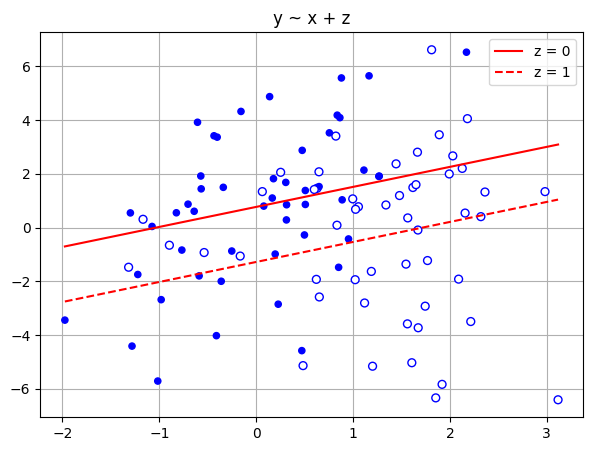

In [7]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs), b0_linear + b1_linear * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs) + b2_linear, b0_linear + b1_linear * max(xs) + b2_linear],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z')
ax.legend()
ax.set_axisbelow(True)

In [8]:
model_inter = bambi.Model('y ~ x + z + x:z', ex1_df)
fit_inter = model_inter.fit()
summ_inter = arviz.summary(fit_inter, var_names='~mu')
b0_inter = summ_inter['mean']['Intercept']
b1_inter = summ_inter['mean']['x']
b2_inter = summ_inter['mean']['z']
b3_inter = summ_inter['mean']['x:z']
arviz.summary(fit_inter, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z, x:z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.692,0.196,2.336,3.066,0.003,0.003,3807.0,2750.0,1.0
Intercept,0.741,0.383,0.003,1.456,0.006,0.006,3871.0,3179.0,1.0
x,1.737,0.477,0.832,2.610,0.009,0.007,2721.0,2734.0,1.0
z,-1.017,0.756,-2.466,0.374,0.013,0.012,3499.0,2655.0,1.0
x:z,-1.776,0.614,-2.910,-0.605,0.013,0.010,2283.0,2153.0,1.0


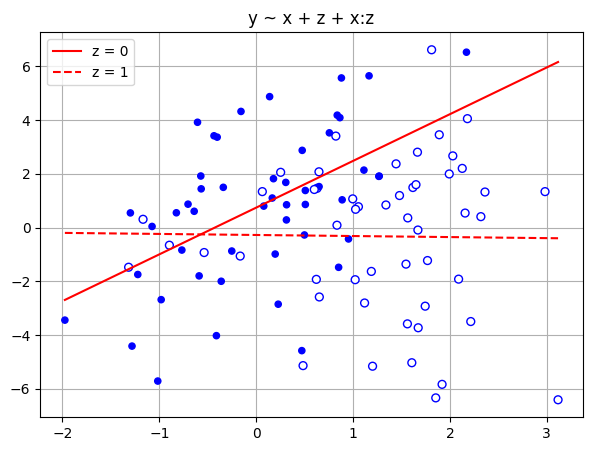

In [9]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_inter + b1_inter * min(xs), b0_inter + b1_inter * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [
        b0_inter + (b1_inter + b3_inter) * min(xs) + b2_inter,
        b0_inter + (b1_inter + b3_inter) * max(xs) + b2_inter,
    ],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z + x:z')
ax.legend()
ax.set_axisbelow(True)

## 10.2, Regression with interactions

> Here is the output from a fitted linear regression of outcome $y$ on
> pre-treatment predictor $x$, treatment indicator $z$, and their interaction:

```
            Median MAD_SD
(Intercept) 1.2    0.2
x           1.6    0.4
z           2.7    0.3
x:z         0.7    0.5
 
Auxiliary parameter(s):
      Median MAD_SD`
sigma 0.5    0.0
```

> (a) Write the equation of the estimated regression line of $y$ on $x$ for the
>     treatment group, and the equation of the estimated regression line of $y$
>     on $x$ for the control group.
> 
> (b) Graph with pen on paper the two regression lines, assuming the values of
>     $x$ fall in the range (0, 10). On this graph also include a scatterplot of
>     data (using open circles for treated units and dots for controls) that are
>     consistent with the fitted model.

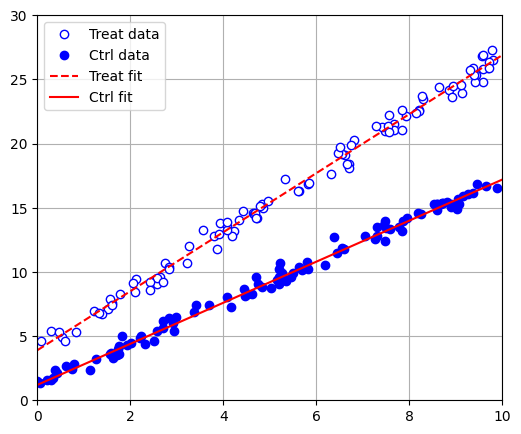

In [10]:
rng = fresh_prng('Exercise 10.2')

x_t = rng.uniform(low=0, high=10, size=100)
y_t = rng.normal(loc=(3.9 + 2.3 * x_t), scale=0.5)
x_c = rng.uniform(low=0, high=10, size=100)
y_c = rng.normal(loc=(1.2 + 1.6 * x_c), scale=0.5)

fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(x_t, y_t, color='w', marker='o', markeredgecolor='b', label='Treat data', linewidth=0)
ax.plot(x_c, y_c, color='b', marker='o', label='Ctrl data', linewidth=0)
ax.plot([0, 10], [3.9, 3.9 + 23], 'r--', label='Treat fit')
ax.plot([0, 10], [1.2, 1.2 + 16], 'r-', label='Ctrl fit')
ax.set_xlim(0, 10)
ax.set_ylim(0, 30)
ax.grid()
ax.legend()
ax.set_axisbelow(True)

## 10.3, Checking statistical significance

> In this exercise and the next, you will simulate two variables that are
> statistically independent of each other to see what happens when we run a
> regression to predict one from the other. Generate 1000 data points from a
> normal distribution with mean 0 and standard deviation 1 by typing
> `var1 <- rnorm(1000,0,1)` in R. Generate another variable in the same way
> (call it `var2`). Run a regression of one variable on the other. Is the slope
> coefficient “statistically significant”? We do not recommend summarizing
> regressions in this way, but it can be useful to understand how this works,
> given that others will do so.

In [11]:
rng = fresh_prng('Exercise 10.3')

In [12]:
var1 = rng.normal(size=1000)
var2 = rng.normal(size=1000)
res = stats.linregress(var1, var2)
print(f'Slope: {res.slope:0.3f}')
print(f'Slope std err: {res.stderr:0.3f}')

Slope: 0.003
Slope std err: 0.032


## 10.4, Simulation study of statistical significance

> Continuing the previous exercise, run a simulation repeating this process 100
> times. This can be done using a loop. From each simulation, save the $z$-score
> (the estimated coefficient of `var1` divided by its standard error). If the
> absolute value of the $z$-score exceeds 2, the estimate is “statistically
> significant.”
> 
> To perform this computation, we start by creating an empty vector of
> $z$-scores filled with missing values (NAs). Another approach is to start with
> `z_scores <- numeric(length=100)`, which would set up a vector of zeroes. In
> general, however, we prefer to initialize with NAs, because then when there is
> a bug in the code, it sometimes shows up as NAs in the final results, alerting
> us to the problem. Here is code to perform the simulation:

```
z_scores <- rep(NA, 100)
for (k in 1:100) {
  var1 <- rnorm(1000, 0, 1)
  var2 <- rnorm(1000, 0, 1)
  fake <- data.frame(var1, var2)
  fit <- stan_glm(var2 ~ var1, data=fake)
  z_scores[k] <- coef(fit)[2] / se(fit)[2]
}
```

> How many of these 100 $z$-scores exceed 2 in absolute value, thus achieving
> the conventional level of statistical significance?

In [13]:
rng = fresh_prng('Exercise 10.4')
statsig_count = 0
for _ in range(100):
    var1 = rng.normal(size=1000)
    var2 = rng.normal(size=1000)
    res = stats.linregress(var1, var2)
    if abs(res.slope) > (2 * res.stderr):
        statsig_count += 1
print(statsig_count)

2


## 10.5, Regression modeling and prediction

> The
> [folder `KidIQ`](https://github.com/avehtari/ROS-Examples/tree/master/KidIQ/)
> contains a subset of the children and mother data discussed
> earlier in the chapter. You have access to children’s test scores at age 3,
> mother’s education, and the mother’s age at the time she gave birth for a
> sample of 400 children.
> 
> (a) Fit a regression of child test scores on mother’s age, display the data
>     and fitted model, check assumptions, and interpret the slope coefficient.
>     Based on this analysis, when do you recommend mothers should give birth?
>     What are you assuming in making this recommendation?
> 
> (b) Repeat this for a regression that further includes mother’s education,
>     interpreting both slope coefficients in this model. Have your conclusions
>     about the timing of birth changed?
> 
> (c) Now create an indicator variable reflecting whether the mother has
>     completed high school or not. Consider interactions between high school
>     completion and mother’s age. Also create a plot that shows the separate
>     regression lines for each high school completion status group.
> 
> (d) Finally, fit a regression of child test scores on mother’s age and
>     education level for the first 200 children and use this model to predict
>     test scores for the next 200. Graphically display comparisons of the
>     predicted and actual scores for the final 200 children.

In [14]:
iq_df = pandas.read_csv('/home/bgawalt/ros/datasets/kidiq.csv')
iq_df.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,434.000000,434.000000,434.000000,434.000000,434.000000
mean,86.797235,0.785714,100.000000,2.896313,22.785714
std,20.410688,0.410799,15.000000,1.181394,2.701070
min,20.000000,0.000000,71.037405,1.000000,17.000000
25%,74.000000,1.000000,88.660321,2.000000,21.000000
50%,90.000000,1.000000,97.915254,3.000000,23.000000
75%,102.000000,1.000000,110.272742,4.000000,25.000000
max,144.000000,1.000000,138.893106,4.000000,29.000000


### 10.5(a)

In [15]:
model_age = bambi.Model('kid_score ~ mom_age', iq_df)
fit_age = model_age.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [16]:
summ_age = arviz.summary(fit_age, var_names='~mu')
b0_age = summ_age['mean']['Intercept']
b1_age = summ_age['mean']['mom_age']
arviz.summary(fit_age, var_names='~mu')

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,20.382,0.698,19.148,21.757,0.009,0.011,6085.0,2792.0,1.0
Intercept,70.843,8.352,56.027,86.870,0.110,0.131,5799.0,3245.0,1.0
mom_age,0.701,0.364,0.003,1.357,0.005,0.006,5698.0,3201.0,1.0


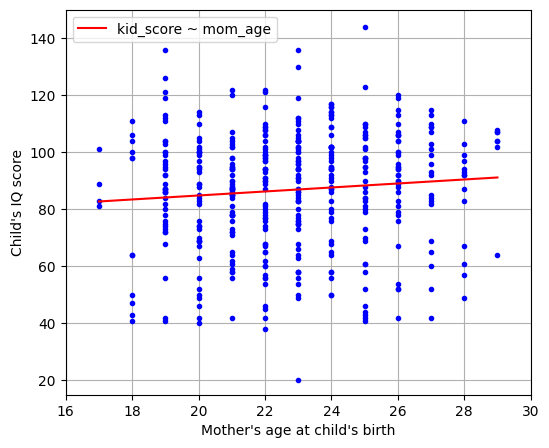

In [17]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(iq_df['mom_age'], iq_df['kid_score'], 'b.')
ax.plot(
    [17, 29],
    [b0_age + b1_age * 17, b0_age + b1_age * 29],
    'r-',
    label='kid_score ~ mom_age',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_axisbelow(True)

### 10.5(b)

In [18]:
model_lin = bambi.Model('kid_score ~ mom_age + mom_hs', iq_df)
fit_lin = model_lin.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [19]:
summ_lin = arviz.summary(fit_lin, var_names='~mu')
b0_lin = summ_lin['mean']['Intercept']
b1_lin = summ_lin['mean']['mom_age']
b2_lin = summ_lin['mean']['mom_hs']
arviz.summary(fit_lin, var_names='~mu')

/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,19.876,0.677,18.593,21.135,0.009,0.011,6024.0,3494.0,1.0
Intercept,70.578,8.090,56.508,86.365,0.100,0.122,6514.0,3440.0,1.0
mom_age,0.320,0.364,-0.371,0.977,0.005,0.005,5646.0,3449.0,1.0
mom_hs,11.346,2.424,6.473,15.645,0.034,0.036,5173.0,2976.0,1.0


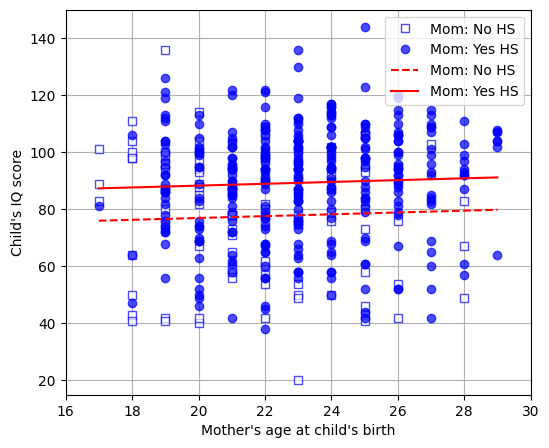

In [20]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    iq_df[iq_df['mom_hs'] == 0]['mom_age'],
    iq_df[iq_df['mom_hs'] == 0]['kid_score'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Mom: No HS',
    alpha=0.7,
)
ax.plot(
    iq_df[iq_df['mom_hs'] == 1]['mom_age'],
    iq_df[iq_df['mom_hs'] == 1]['kid_score'],
    color='b',
    linewidth=0,
    marker='o',
    label='Mom: Yes HS',
    alpha=0.7,
)
ax.plot(
    [17, 29],
    [b0_lin + b1_lin * 17, b0_lin + b1_lin * 29],
    'r--',
    label='Mom: No HS',
)
ax.plot(
    [17, 29],
    [b0_lin + b1_lin * 17 + b2_lin, b0_lin + b1_lin * 29 + b2_lin],
    'r-',
    label='Mom: Yes HS',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_axisbelow(True)

### 10.5(c)

In [21]:
model_inter = bambi.Model('kid_score ~ mom_age + mom_hs + mom_age:mom_hs', iq_df)
fit_inter = model_inter.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs, mom_age:mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [22]:
summ_inter = arviz.summary(fit_inter)
b0_inter = summ_inter['mean']['Intercept']
b1_inter = summ_inter['mean']['mom_age']
b2_inter = summ_inter['mean']['mom_hs']
b3_inter = summ_inter['mean']['mom_age:mom_hs']
arviz.summary(fit_inter)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,19.736,0.675,18.483,20.997,0.013,0.011,2895.0,2314.0,1.0
Intercept,108.714,16.172,79.580,140.098,0.425,0.292,1453.0,1889.0,1.0
mom_age,-1.439,0.738,-2.846,-0.096,0.019,0.013,1440.0,1695.0,1.0
mom_hs,-38.931,18.521,-73.800,-4.251,0.511,0.343,1307.0,1564.0,1.0
mom_age:mom_hs,2.284,0.831,0.691,3.818,0.023,0.016,1289.0,1706.0,1.0


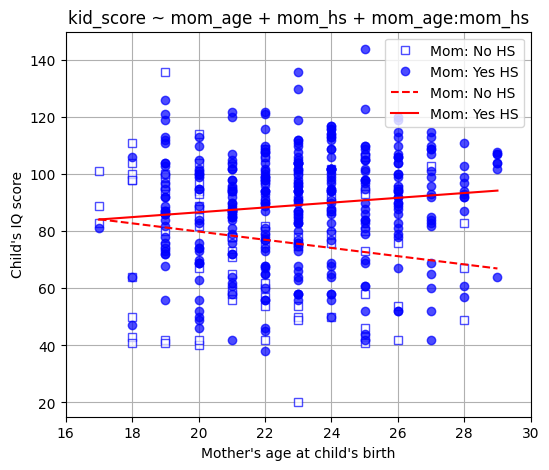

In [23]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot(
    iq_df[iq_df['mom_hs'] == 0]['mom_age'],
    iq_df[iq_df['mom_hs'] == 0]['kid_score'],
    markeredgecolor='b',
    linewidth=0,
    marker='s',
    color='w',
    label='Mom: No HS',
    alpha=0.7,
)
ax.plot(
    iq_df[iq_df['mom_hs'] == 1]['mom_age'],
    iq_df[iq_df['mom_hs'] == 1]['kid_score'],
    color='b',
    linewidth=0,
    marker='o',
    label='Mom: Yes HS',
    alpha=0.7,
)
ax.plot(
    [17, 29],
    [b0_inter + b1_inter * 17, b0_inter + b1_inter * 29],
    'r--',
    label='Mom: No HS',
)
ax.plot(
    [17, 29],
    [
        b0_inter + (b1_inter + b3_inter) * 17 + b2_inter,
        b0_inter + (b1_inter + b3_inter) * 29 + b2_inter,
    ],
    'r-',
    label='Mom: Yes HS',
)
ax.grid()
ax.legend()
ax.set_ylabel("Child's IQ score")
ax.set_xlabel("Mother's age at child's birth")
ax.set_xlim(16, 30)
ax.set_ylim(15, 150)
ax.set_title('kid_score ~ mom_age + mom_hs + mom_age:mom_hs')
ax.set_axisbelow(True)

### 10.5(d)

In [24]:
iq_df_train = iq_df[:200]
iq_df_train.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,92.980000,0.830000,103.772799,2.965000,23.275000
std,17.604237,0.376575,14.709159,1.153441,2.738039
min,42.000000,0.000000,71.037405,1.000000,17.000000
25%,84.000000,1.000000,92.764078,2.000000,21.000000
50%,95.500000,1.000000,100.937583,3.000000,23.000000
75%,105.000000,1.000000,114.337615,4.000000,25.000000
max,144.000000,1.000000,138.893106,4.000000,29.000000


In [25]:
iq_df_test = iq_df[200:]
iq_df_test.describe()

,kid_score,mom_hs,mom_iq,mom_work,mom_age
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,81.512821,0.747863,96.775385,2.837607,22.367521
std,21.181260,0.435170,14.514980,1.204122,2.602733
min,20.000000,0.000000,74.230245,1.000000,17.000000
25%,67.250000,0.250000,85.033956,2.000000,21.000000
50%,84.000000,1.000000,93.032053,3.000000,22.000000
75%,97.000000,1.000000,107.150411,4.000000,24.000000
max,136.000000,1.000000,136.577170,4.000000,29.000000


In [33]:
model_200 = bambi.Model('kid_score ~ mom_age + mom_hs + mom_age:mom_hs', iq_df_train)
fit_200 = model_200.fit()
arviz.summary(fit_200)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, mom_age, mom_hs, mom_age:mom_hs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,17.589,0.888,15.993,19.296,0.017,0.016,2738.0,2374.0,1.0
Intercept,115.072,22.923,69.536,155.435,0.609,0.404,1414.0,1703.0,1.0
mom_age,-1.172,1.045,-3.063,0.904,0.028,0.019,1418.0,1704.0,1.0
mom_hs,-36.948,25.390,-83.435,10.822,0.685,0.485,1370.0,1815.0,1.0
mom_age:mom_hs,1.834,1.140,-0.309,3.923,0.031,0.022,1349.0,1757.0,1.0


In [37]:
@dataclasses.dataclass(frozen=True)
class KidIQPrediction:
    actual: float
    p025: float
    p25: float
    p50: float
    p75: float
    p975: float

    def plot(self, ax: pyplot.Axes):
        ax.plot([self.actual, self.actual], [self.p025, self.p975], 'b-', linewidth=1, alpha=0.7)
        ax.plot([self.actual, self.actual], [self.p25, self.p75], 'b-', linewidth=3, alpha=0.7)
        ax.plot([self.actual,], [self.p50,], 'b.')

In [38]:
kiq_preds = []
rng = fresh_prng("Exercise 10.5(d)")
for _, test_row in iq_df_test.iterrows():
    preds = []
    for chain in range(4):
        sims = fit_200.posterior.sel(chain=0).to_dataframe()
        for _, sim_row in sims.iterrows():
            preds.append(
                sim_row["Intercept"] +
                sim_row["mom_age"] * test_row["mom_age"] +
                sim_row["mom_hs"] * test_row["mom_hs"] +
                sim_row["mom_age:mom_hs"] * test_row["mom_age"] * test_row["mom_hs"] +
                rng.normal(0, sim_row["sigma"])
            )
    qs = numpy.quantile(preds, q=[0.025, 0.25, 0.5, 0.75, 0.975])
    kiq_preds.append(KidIQPrediction(
        actual=test_row["kid_score"],
        p025=qs[0],
        p25=qs[1],
        p50=qs[2],
        p75=qs[3],
        p975=qs[4],
    ))

Text(0, 0.5, 'Predicted Child IQ')

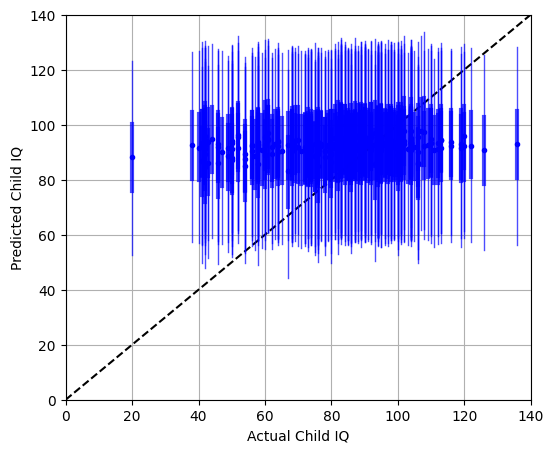

In [39]:
fig = pyplot.figure(figsize=(6, 5))
ax = fig.gca()
ax.plot([0, 140], [0, 140], 'k--')
for kiqp in kiq_preds:
    kiqp.plot(ax)
ax.grid()
ax.set_xlabel('Actual Child IQ')
ax.set_xlim(0, 140)
ax.set_ylim(0, 140)
ax.set_ylabel('Predicted Child IQ')